In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet

In [25]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vishnusreekumar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vishnusreekumar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vishnusreekumar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vishnusreekumar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/vishnusreekumar/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/vishnusreekumar/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

## 1. Data Exploration and Preprocessing

In [3]:
df = pd.read_csv("blogs.csv.xls")
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [6]:
df.shape

(2000, 2)

In [7]:
df.isnull().sum()

Data      0
Labels    0
dtype: int64

In [8]:
df['Labels'].value_counts()


Labels
alt.atheism                 100
comp.graphics               100
talk.politics.misc          100
talk.politics.mideast       100
talk.politics.guns          100
soc.religion.christian      100
sci.space                   100
sci.med                     100
sci.electronics             100
sci.crypt                   100
rec.sport.hockey            100
rec.sport.baseball          100
rec.motorcycles             100
rec.autos                   100
misc.forsale                100
comp.windows.x              100
comp.sys.mac.hardware       100
comp.sys.ibm.pc.hardware    100
comp.os.ms-windows.misc     100
talk.religion.misc          100
Name: count, dtype: int64

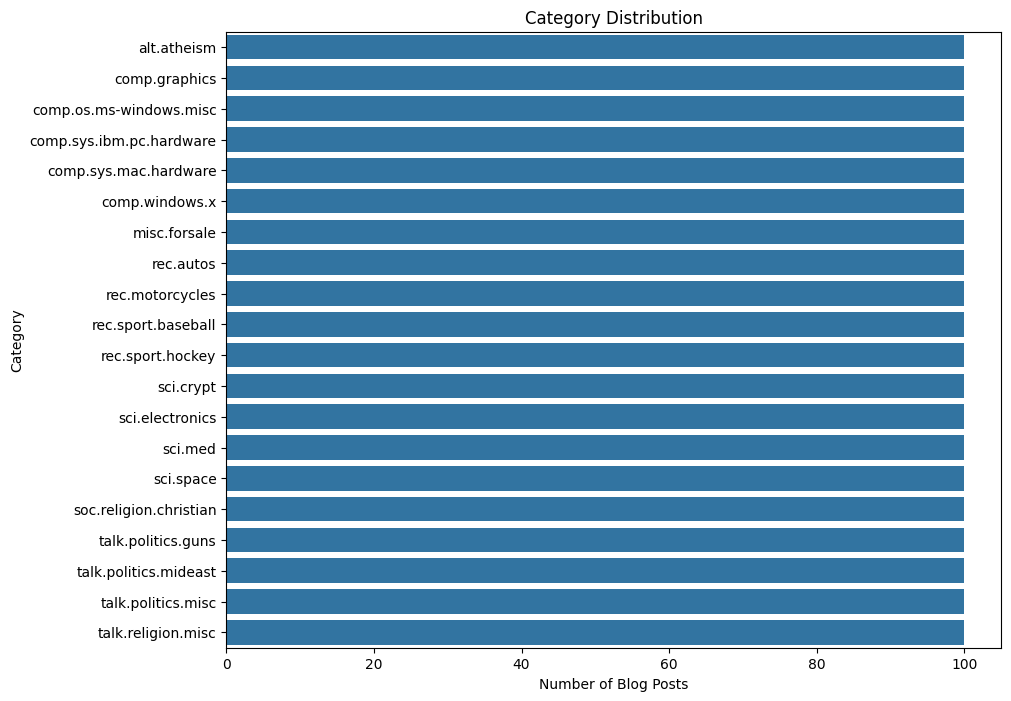

In [17]:
plt.figure(figsize=(10,8))
sns.countplot(y=df['Labels'])   # horizontal bars
plt.title("Category Distribution")
plt.xlabel("Number of Blog Posts")
plt.ylabel("Category")
plt.show()


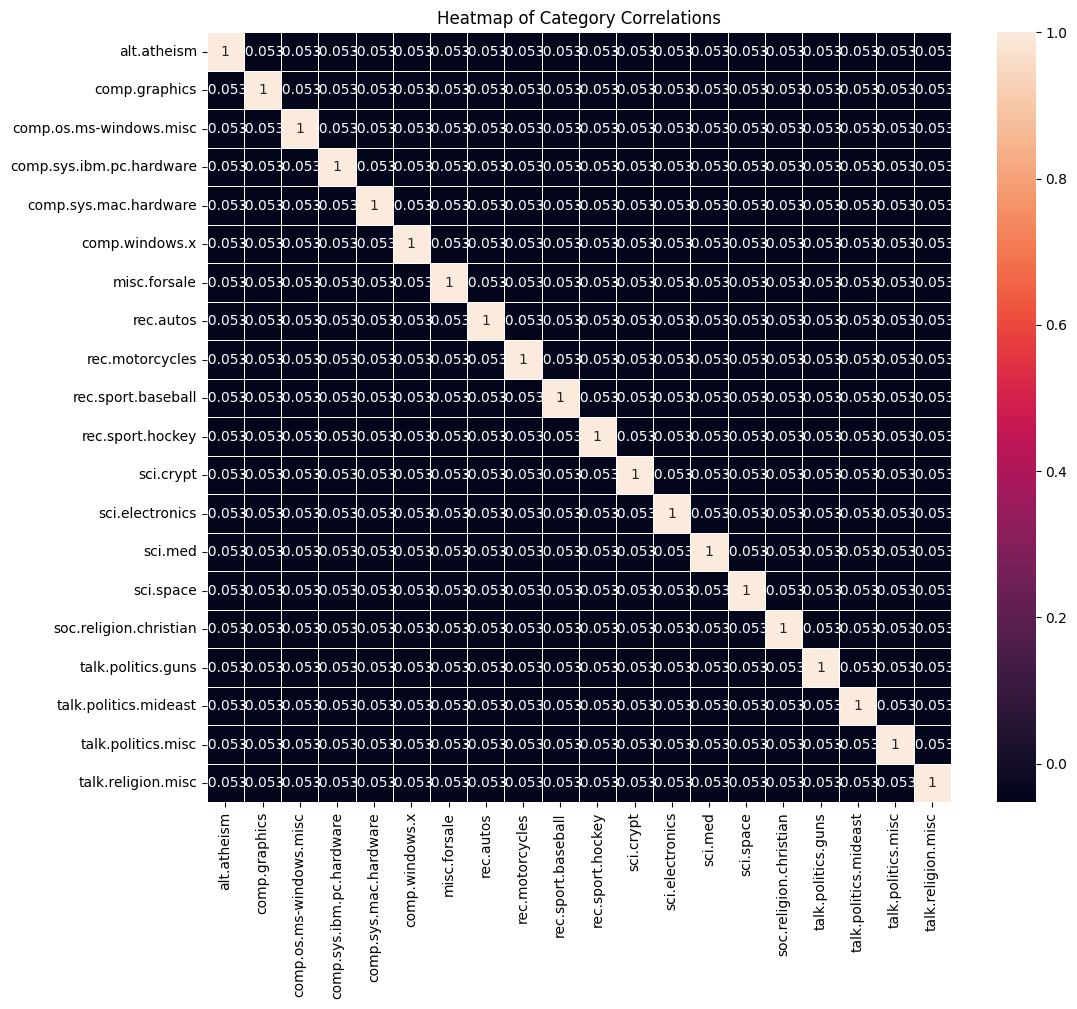

In [18]:
label_dummies = pd.get_dummies(df['Labels'])
corr = label_dummies.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, linewidths=0.5)
plt.title("Heatmap of Category Correlations")
plt.show()

In [21]:
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {'J': wordnet.ADJ,
                'N': wordnet.NOUN,
                'V': wordnet.VERB,
                'R': wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)               # remove punctuation/numbers
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stopwords.words('english')]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in tokens]  # POS-based lemmatization
    return " ".join(tokens)

In [26]:
df['cleaned_text'] = df['Data'].apply(clean_text)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [28]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_text']).toarray()

In [29]:
y = df['Labels']

## 2. Naive Bayes Model for Text Classification

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1600, 5000)
Test shape: (400, 5000)


In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix

In [34]:
# define model:
nb_model = MultinomialNB()

In [36]:
# train the defined model
nb_model.fit(X_train, y_train)

MultinomialNB()

In [37]:
# model prediction:
y_pred = nb_model.predict(X_test)

In [38]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8525

Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.50      0.78      0.61        18
           comp.graphics       0.70      0.89      0.78        18
 comp.os.ms-windows.misc       0.91      0.91      0.91        22
comp.sys.ibm.pc.hardware       0.88      0.84      0.86        25
   comp.sys.mac.hardware       0.87      0.95      0.91        21
          comp.windows.x       0.96      0.88      0.92        25
            misc.forsale       1.00      0.72      0.84        18
               rec.autos       0.95      1.00      0.97        18
         rec.motorcycles       0.88      0.94      0.91        16
      rec.sport.baseball       0.86      1.00      0.92        18
        rec.sport.hockey       0.94      1.00      0.97        15
               sci.crypt       0.90      1.00      0.95        19
         sci.electronics       0.76      0.81      0.79        16
                 sci.med   

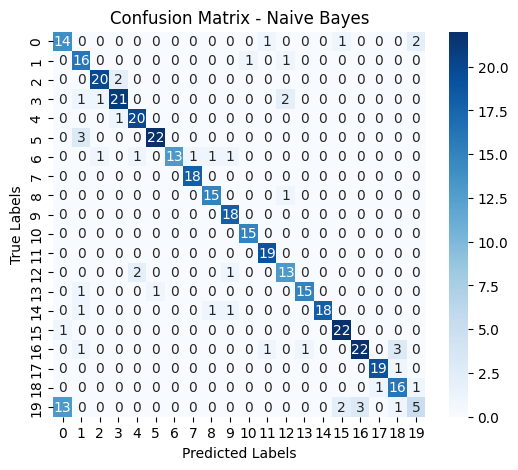

In [39]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

## 3. Sentiment Analysis

In [43]:
from textblob import TextBlob

In [44]:
# function to get sentiment polarity
def get_sentiment(text):
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [45]:
# applying sentiment analysis
df['Sentiment'] = df['Data'].apply(get_sentiment)

In [46]:
df[['Data', 'Sentiment']].head()

,Data,Sentiment
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,Negative
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Positive
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,Positive


In [47]:
print("\nSentiment Distribution:\n", df['Sentiment'].value_counts())


Sentiment Distribution:
 Sentiment
Positive    1543
Negative     457
Name: count, dtype: int64


/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_6476/2555805418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='coolwarm')


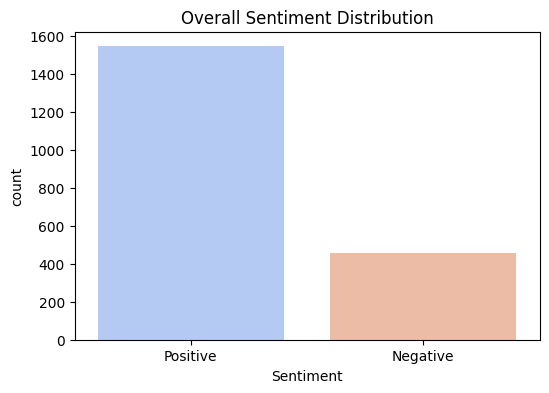

In [48]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Sentiment', data=df, palette='coolwarm')
plt.title("Overall Sentiment Distribution")
plt.show()


Sentiment Distribution by Category:
 Sentiment                 Negative  Positive
Labels                                      
alt.atheism                     23        77
comp.graphics                   24        76
comp.os.ms-windows.misc         22        78
comp.sys.ibm.pc.hardware        20        80
comp.sys.mac.hardware           24        76
comp.windows.x                  27        73
misc.forsale                    16        84
rec.autos                       17        83
rec.motorcycles                 26        74
rec.sport.baseball              29        71
rec.sport.hockey                34        66
sci.crypt                       19        81
sci.electronics                 19        81
sci.med                         29        71
sci.space                       27        73
soc.religion.christian          13        87
talk.politics.guns              30        70
talk.politics.mideast           22        78
talk.politics.misc              22        78
talk.religion.mis

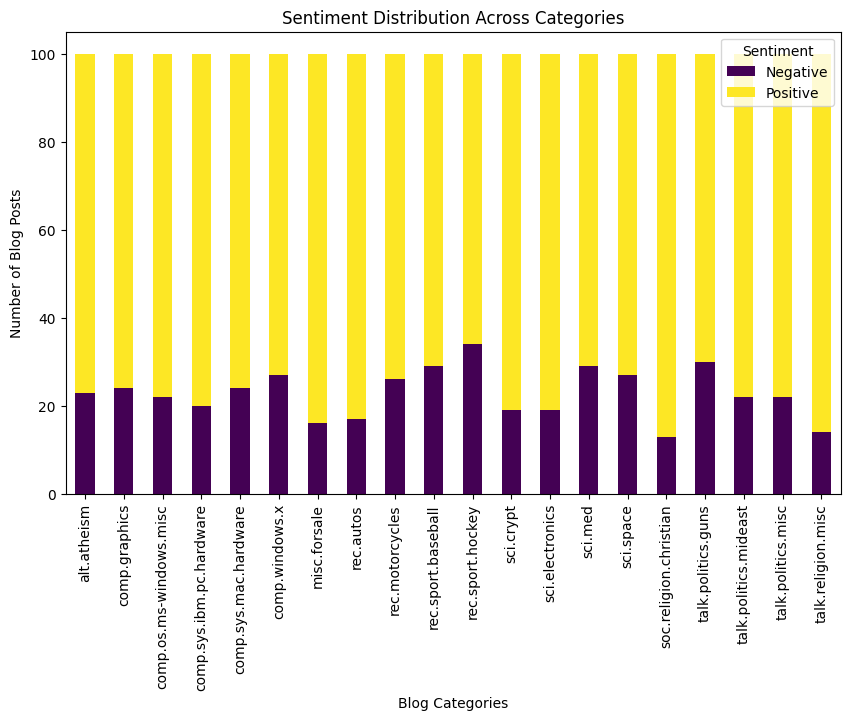

In [49]:
sentiment_by_category = df.groupby(['Labels', 'Sentiment']).size().unstack().fillna(0)
print("\nSentiment Distribution by Category:\n", sentiment_by_category)
# visualize sentiment by category
sentiment_by_category.plot(kind='bar', figsize=(10, 6), stacked=True, colormap='viridis')
plt.title("Sentiment Distribution Across Categories")
plt.ylabel("Number of Blog Posts")
plt.xlabel("Blog Categories")
plt.legend(title='Sentiment')
plt.show()

In [50]:
# Most categories have more positive than negative blog posts. A few (like sports categories) show slightly higher negative counts, but overall positive sentiment clearly dominates across all categories.

## 4. Evaluation

In [53]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(classification_report(y_test, y_pred))

Accuracy : 0.8525
Precision: 0.8580
Recall   : 0.8525
F1 Score : 0.8446
                          precision    recall  f1-score   support

             alt.atheism       0.50      0.78      0.61        18
           comp.graphics       0.70      0.89      0.78        18
 comp.os.ms-windows.misc       0.91      0.91      0.91        22
comp.sys.ibm.pc.hardware       0.88      0.84      0.86        25
   comp.sys.mac.hardware       0.87      0.95      0.91        21
          comp.windows.x       0.96      0.88      0.92        25
            misc.forsale       1.00      0.72      0.84        18
               rec.autos       0.95      1.00      0.97        18
         rec.motorcycles       0.88      0.94      0.91        16
      rec.sport.baseball       0.86      1.00      0.92        18
        rec.sport.hockey       0.94      1.00      0.97        15
               sci.crypt       0.90      1.00      0.95        19
         sci.electronics       0.76      0.81      0.79        16
   

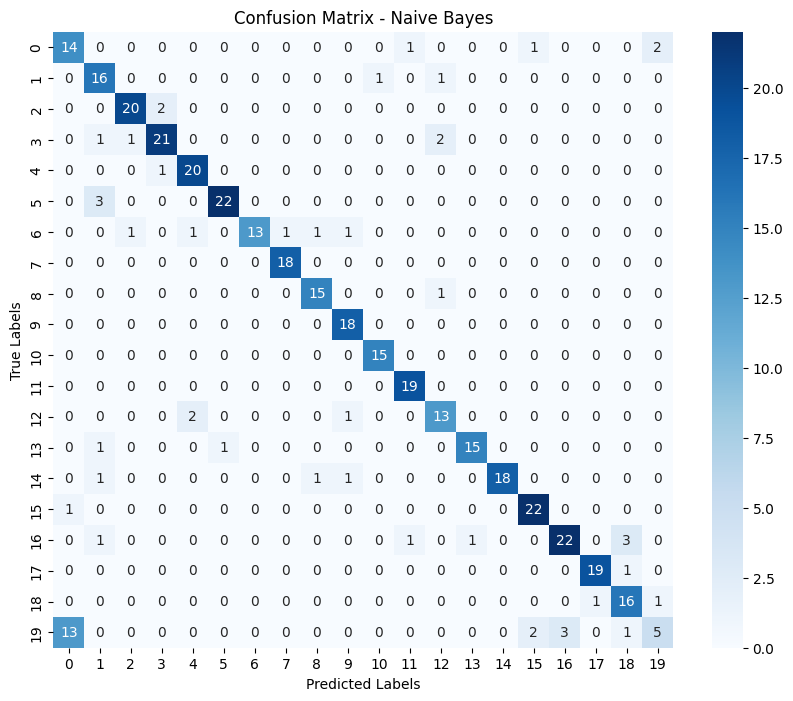

In [54]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#### Model Performance & Challenges
    * Many blog categories contain similar vocabulary, causing overlaps.
    
    * Some posts are long and contain mixed topics, making classification harder.
    
    * TF-IDF reduces noise but still cannot fully capture context or semantics.

#### Sentiment Analysis & Insights

    * Most categories show mainly positive sentiment, with fewer negative posts. This suggests the blogs are generally informative or positive in tone, with only a few topics showing stronger negative opinions.